In [1]:
# Employee Turnover Analytics - Single-file end-to-end script for Google Colab
# Paste entire block into one Colab cell and run.
# Requires: pandas, numpy, matplotlib, seaborn, scikit-learn, imbalanced-learn, joblib, shap (optional)
# If a package is missing, uncomment the pip install lines below and re-run.

# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib shap --quiet

import os, sys, warnings
warnings.filterwarnings('ignore')

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report,
                             precision_recall_curve)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.cluster import KMeans
import joblib
import datetime


In [2]:
# ---------- Step 0: Load dataset (Colab friendly) ----------
# The program looks for 'HR_comma_sep.csv' in the current working dir.
# If not found, it will prompt you to upload via Colab file upload dialog.

csv_default = 'HR_comma_sep.csv'  # default filename expected
csv_path = csv_default

if not os.path.exists(csv_path):
    print(f"File '{csv_path}' not found. Please upload the HR CSV file (HR_comma_sep.csv).")
    try:
        from google.colab import files
        uploaded = files.upload()
        # copy the first uploaded file path
        if len(uploaded) > 0:
            csv_path = next(iter(uploaded.keys()))
            print("Uploaded file:", csv_path)
        else:
            raise Exception("No file uploaded.")
    except Exception as e:
        print("Automatic upload failed or not in Colab environment. Please ensure the file is accessible.")
        raise e

# Read CSV
df = pd.read_csv(csv_path)
print("Data loaded. Shape:", df.shape)
print("Columns:", df.columns.tolist())

# ---------- Step 1: Basic data inspection & quality checks ----------
print("\n--- Basic info ---")
print(df.info())
print("\n--- First 5 rows ---")
print(df.head())

print("\n--- Describe (numerical) ---")
print(df.describe().T)

print("\n--- Missing values per column ---")
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing>0] if missing.sum()>0 else "No missing values found.")

print("\n--- Duplicates ---")
dups = df.duplicated().sum()
print("Duplicated rows:", dups)
if dups > 0:
    print("Dropping duplicates.")
    df = df.drop_duplicates()
    print("New shape:", df.shape)

# Sanity checks for ranges
print("\n--- Sanity checks (min/max) ---")
if 'satisfaction_level' in df.columns and 'last_evaluation' in df.columns:
    print("satisfaction_level min/max:", df['satisfaction_level'].min(), df['satisfaction_level'].max())
    print("last_evaluation min/max:", df['last_evaluation'].min(), df['last_evaluation'].max())
if 'number_project' in df.columns:
    print("number_project unique values:", sorted(df['number_project'].unique()))
if 'average_montly_hours' in df.columns:
    print("average_montly_hours stats:\n", df['average_montly_hours'].describe())
if 'time_spend_company' in df.columns:
    print("time_spend_company counts:\n", df['time_spend_company'].value_counts().sort_index())


Data loaded. Shape: (14999, 10)
Columns: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'sales', 'salary']

--- Basic info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), o


--- Correlation heatmap (numerical features) ---


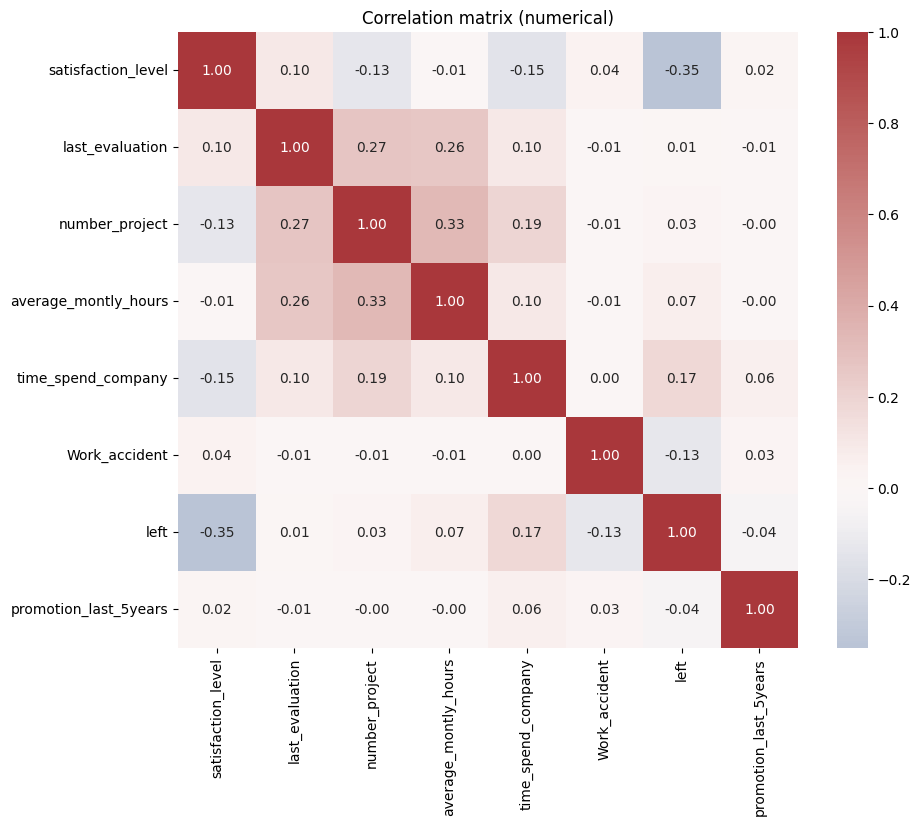


Features most correlated with 'left' (absolute):
satisfaction_level       0.350558
time_spend_company       0.173295
Work_accident            0.125436
average_montly_hours     0.070409
promotion_last_5years    0.044657
number_project           0.030928
last_evaluation          0.013520
Name: left, dtype: float64


In [3]:
# Fix column name typos (if any)
# The original dataset uses 'average_montly_hours' (typo 'montly'); keep it as-is for reproducibility.
# If you want to rename, uncomment:
# df.rename(columns={'average_montly_hours':'average_monthly_hours'}, inplace=True)

# Ensure 'left' is numeric 0/1
if df['left'].dtype != np.number and not np.issubdtype(df['left'].dtype, np.integer):
    df['left'] = df['left'].astype(int)

# ---------- Step 2: EDA - Correlation heatmap (numeric features) ----------
print("\n--- Correlation heatmap (numerical features) ---")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10,8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlation matrix (numerical)')
plt.show()

# Print correlations with 'left' sorted by absolute value
if 'left' in corr.columns:
    left_corr = corr['left'].drop('left').abs().sort_values(ascending=False)
    print("\nFeatures most correlated with 'left' (absolute):")
    print(left_corr)



--- Distribution plots for satisfaction_level, last_evaluation, average_montly_hours ---


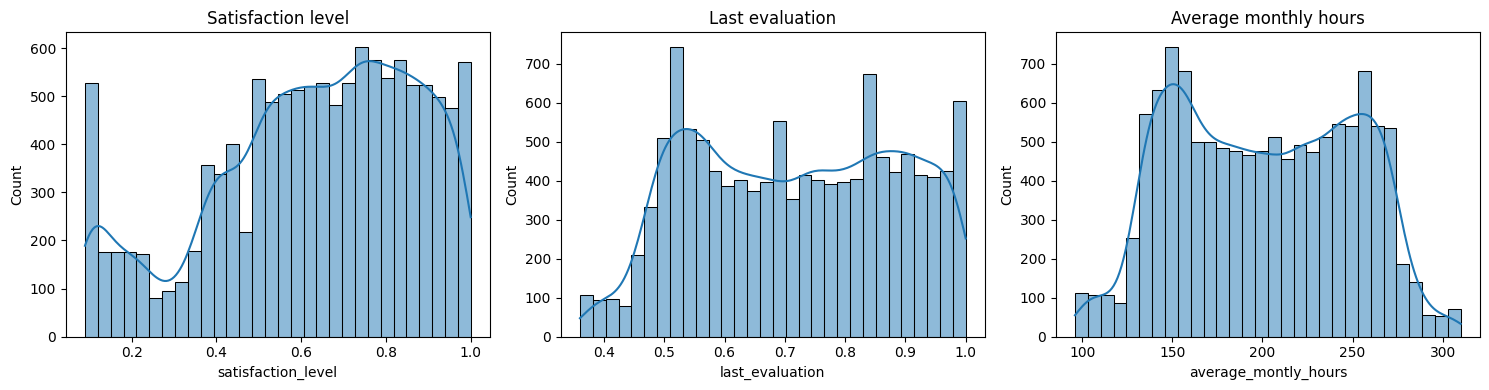

In [4]:
# ---------- Step 3: Distribution plots ----------
print("\n--- Distribution plots for satisfaction_level, last_evaluation, average_montly_hours ---")
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
sns.histplot(df['satisfaction_level'], kde=True, bins=30)
plt.title('Satisfaction level')
plt.xlabel('satisfaction_level')

plt.subplot(1,3,2)
sns.histplot(df['last_evaluation'], kde=True, bins=30)
plt.title('Last evaluation')
plt.xlabel('last_evaluation')

plt.subplot(1,3,3)
sns.histplot(df['average_montly_hours'], kde=True, bins=30)
plt.title('Average monthly hours')
plt.xlabel('average_montly_hours')

plt.tight_layout()
plt.show()

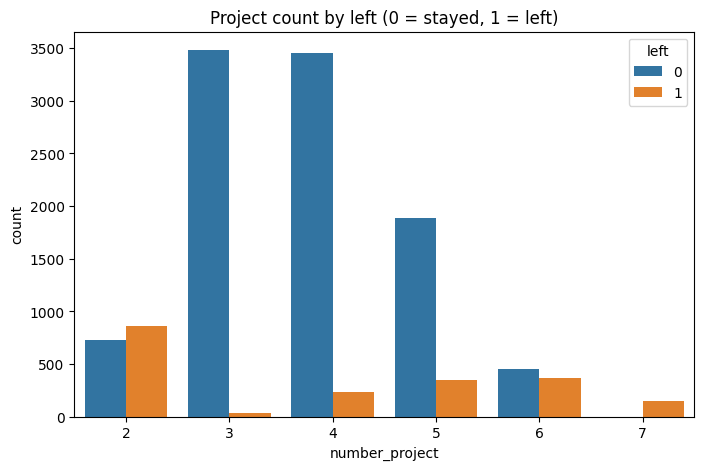


% distribution of left by project count (rows sum to 100):
left                0       1
number_project               
2               45.83   54.17
3               98.92    1.08
4               93.57    6.43
5               84.64   15.36
6               55.08   44.92
7                0.00  100.00

--- KMeans clustering (k=3) on employees who left using satisfaction_level & last_evaluation ---


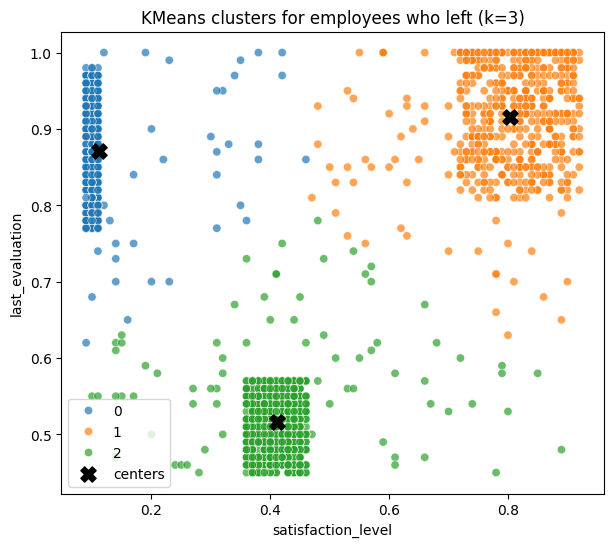


Cluster sizes and mean values:
        satisfaction_level       last_evaluation      
                      mean count            mean count
cluster                                               
0                    0.112   531           0.871   531
1                    0.804   553           0.915   553
2                    0.411   907           0.516   907

Cluster 0 mean satisfaction=0.112, evaluation=0.871
 -> High performers with low satisfaction: high risk, consider promotion/compensation/retention package.

Cluster 1 mean satisfaction=0.804, evaluation=0.915
 -> Moderate/high satisfaction: check other factors (workload, growth).

Cluster 2 mean satisfaction=0.411, evaluation=0.516
 -> Moderate/high satisfaction: check other factors (workload, growth).


In [5]:
# ---------- Step 4: Bar plot of number_project vs left ----------
if 'number_project' in df.columns and 'left' in df.columns:
    plt.figure(figsize=(8,5))
    sns.countplot(x='number_project', hue='left', data=df)
    plt.title('Project count by left (0 = stayed, 1 = left)')
    plt.xlabel('number_project')
    plt.ylabel('count')
    plt.legend(title='left')
    plt.show()

    # Print proportions for interpretation
    proj_left = pd.crosstab(df['number_project'], df['left'], normalize='index')*100
    print("\n% distribution of left by project count (rows sum to 100):")
    print(proj_left.round(2))

# ---------- Step 5: Clustering employees who left (k=3) ----------
print("\n--- KMeans clustering (k=3) on employees who left using satisfaction_level & last_evaluation ---")
if 'left' in df.columns and 'satisfaction_level' in df.columns and 'last_evaluation' in df.columns:
    left_df = df[df['left']==1].copy()
    X_cluster = left_df[['satisfaction_level','last_evaluation']].dropna()
    scaler_cl = StandardScaler()
    X_scaled = scaler_cl.fit_transform(X_cluster)

    kmeans = KMeans(n_clusters=3, random_state=123, n_init=50)
    labels = kmeans.fit_predict(X_scaled)
    left_df = left_df.loc[X_cluster.index].copy()
    left_df['cluster'] = labels

    plt.figure(figsize=(7,6))
    sns.scatterplot(x='satisfaction_level', y='last_evaluation',
                    hue='cluster', palette='tab10', data=left_df, alpha=0.7)
    centers = kmeans.cluster_centers_
    centers_unscaled = scaler_cl.inverse_transform(centers)
    plt.scatter(centers_unscaled[:,0], centers_unscaled[:,1], color='black', marker='X', s=120, label='centers')
    plt.title('KMeans clusters for employees who left (k=3)')
    plt.legend()
    plt.show()

    print("\nCluster sizes and mean values:")
    print(left_df.groupby('cluster')[['satisfaction_level','last_evaluation']].agg(['mean','count']).round(3))

    # Simple interpretation cues to print:
    for c in sorted(left_df['cluster'].unique()):
        means = left_df[left_df['cluster']==c][['satisfaction_level','last_evaluation']].mean()
        print(f"\nCluster {c} mean satisfaction={means['satisfaction_level']:.3f}, evaluation={means['last_evaluation']:.3f}")
        # quick textual suggestion
        if means['satisfaction_level'] < 0.4 and means['last_evaluation'] < 0.5:
            print(" -> Likely disengaged: consider performance review, counseling, role fit.")
        elif means['satisfaction_level'] < 0.4 and means['last_evaluation'] >= 0.5:
            print(" -> High performers with low satisfaction: high risk, consider promotion/compensation/retention package.")
        else:
            print(" -> Moderate/high satisfaction: check other factors (workload, growth).")
else:
    print("Clustering skipped: required columns missing.")

In [6]:
# ---------- Step 6: Preprocessing & SMOTE handling ----------
print("\n--- Preprocessing: categorical to dummies; optional ordinal salary mapping ---")
# Separate features and target
y = df['left']
X = df.drop(columns=['left'])

# Identify categorical columns
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# If salary exists and is categorical ordered ('low','medium','high'), map it to ordinal
if 'salary' in X.columns:
    unique_salary = sorted(X['salary'].dropna().unique())
    print("salary unique values:", unique_salary)
    ordered = ['low','medium','high']
    if set(unique_salary).issubset(set(ordered)):
        print("Mapping salary to ordinal: low->0, medium->1, high->2")
        X['salary'] = X['salary'].map({v:i for i,v in enumerate(ordered)})
        # update columns lists
        if 'salary' in cat_cols:
            cat_cols.remove('salary')
        if 'salary' not in num_cols:
            num_cols.append('salary')

# One-hot encode remaining categorical variables
if len(cat_cols) > 0:
    X_cat = pd.get_dummies(X[cat_cols], drop_first=True)
else:
    X_cat = pd.DataFrame(index=X.index)

X_num = X[num_cols].reset_index(drop=True)
X_cat = X_cat.reset_index(drop=True)
X_proc = pd.concat([X_num, X_cat], axis=1)
print("Processed feature shape:", X_proc.shape)

# Save feature columns for later reference
feature_columns = X_proc.columns.tolist()


--- Preprocessing: categorical to dummies; optional ordinal salary mapping ---
salary unique values: ['high', 'low', 'medium']
Mapping salary to ordinal: low->0, medium->1, high->2
Processed feature shape: (11991, 17)


In [7]:
# ---------- Step 7: Stratified train/test split (80:20) ----------
print("\n--- Stratified train/test split (80:20) with random_state=123) ---")
X_train, X_test, y_train, y_test = train_test_split(
    X_proc, y, test_size=0.2, stratify=y, random_state=123)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train left distribution:\n", y_train.value_counts(normalize=True).round(3))
print("Test left distribution:\n", y_test.value_counts(normalize=True).round(3))

# ---------- Step 8: Upsample training dataset using SMOTE ----------
print("\n--- Applying SMOTE to training set ---")
smote = SMOTE(random_state=123)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("After SMOTE train shape:", X_train_smote.shape)
print("After SMOTE class distribution:\n", pd.Series(y_train_smote).value_counts())

# ---------- Helper: Cross-validation evaluation function using SMOTE inside each fold ----------
def evaluate_model_cv_with_smote(model, X, y, cv=5, threshold=0.5):
    """
    Performs stratified CV where SMOTE is applied inside each fold via ImbPipeline.
    Returns overall metrics (based on cross-validated predictions).
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=123)
    pipeline = ImbPipeline(steps=[('smote', SMOTE(random_state=123)), ('clf', model)])
    # predict probabilities (for AUC) using cross_val_predict
    try:
        y_proba = cross_val_predict(pipeline, X, y, cv=skf, method='predict_proba', n_jobs=-1)[:,1]
    except Exception as e:
        # fallback to predict (some classifiers may not implement predict_proba in pipeline)
        print("Warning: predict_proba failed in cross_val_predict:", e)
        y_proba = cross_val_predict(pipeline, X, y, cv=skf, method='predict', n_jobs=-1)
        # if predictions are class labels, convert to 0/1 floats
        y_proba = np.array(y_proba, dtype=float)
    y_pred = (y_proba >= threshold).astype(int)
    metrics = {
        'accuracy': accuracy_score(y, y_pred),
        'precision': precision_score(y, y_pred, zero_division=0),
        'recall': recall_score(y, y_pred, zero_division=0),
        'f1': f1_score(y, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y, y_proba) if len(np.unique(y_proba))>1 else np.nan
    }
    return metrics, y_pred, y_proba



--- Stratified train/test split (80:20) with random_state=123) ---
Train shape: (9592, 17) Test shape: (2399, 17)
Train left distribution:
 left
0    0.834
1    0.166
Name: proportion, dtype: float64
Test left distribution:
 left
0    0.834
1    0.166
Name: proportion, dtype: float64

--- Applying SMOTE to training set ---
After SMOTE train shape: (15998, 17)
After SMOTE class distribution:
 left
0    7999
1    7999
Name: count, dtype: int64



--- 5-fold CV (SMOTE inside folds) for Logistic Regression, Random Forest, Gradient Boosting ---

Evaluating LogisticRegression ...
LogisticRegression CV metrics:
  accuracy: 0.7879
  precision: 0.4150
  recall: 0.6761
  f1: 0.5143
  roc_auc: 0.8111

Evaluating RandomForest ...
RandomForest CV metrics:
  accuracy: 0.9802
  precision: 0.9655
  recall: 0.9134
  f1: 0.9387
  roc_auc: 0.9815

Evaluating GradientBoosting ...
GradientBoosting CV metrics:
  accuracy: 0.9742
  precision: 0.9154
  recall: 0.9309
  f1: 0.9231
  roc_auc: 0.9845

--- CV metrics comparison ---
                    accuracy  precision  recall      f1  roc_auc
LogisticRegression    0.7879     0.4150  0.6761  0.5143   0.8111
RandomForest          0.9802     0.9655  0.9134  0.9387   0.9815
GradientBoosting      0.9742     0.9154  0.9309  0.9231   0.9845

--- Training models on SMOTE-resampled train set and evaluating on test set ---

Training LogisticRegression on SMOTE-resampled training set...
LogisticRegression test

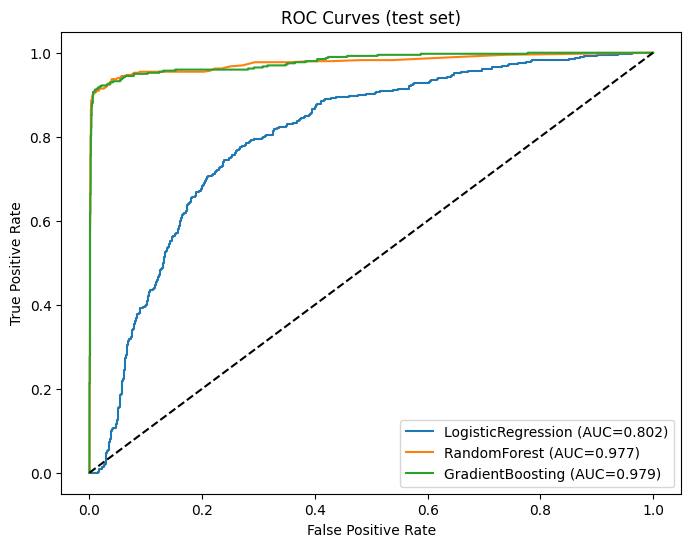

In [8]:
# ---------- Step 9: 5-fold CV for 3 models (Logistic, RF, GBC) ----------
print("\n--- 5-fold CV (SMOTE inside folds) for Logistic Regression, Random Forest, Gradient Boosting ---")
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=123),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=123),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=123)
}

cv_results = {}
for name, model in models.items():
    print(f"\nEvaluating {name} ...")
    metrics, preds_cv, proba_cv = evaluate_model_cv_with_smote(model, X_train, y_train, cv=5, threshold=0.5)
    cv_results[name] = {'metrics': metrics, 'preds_cv': preds_cv, 'proba_cv': proba_cv}
    print(f"{name} CV metrics:")
    for m,v in metrics.items():
        print(f"  {m}: {v:.4f}" if isinstance(v, float) and not np.isnan(v) else f"  {m}: {v}")

# Present CV comparison table
cv_table = pd.DataFrame({name: cv_results[name]['metrics'] for name in cv_results}).T
print("\n--- CV metrics comparison ---")
print(cv_table.round(4))

# ---------- Step 10: Fit models on SMOTE-resampled training set and evaluate on untouched test set ----------
print("\n--- Training models on SMOTE-resampled train set and evaluating on test set ---")
fitted_models = {}
test_results = {}

for name, model in models.items():
    print(f"\nTraining {name} on SMOTE-resampled training set...")
    # Fit model on SMOTE-resampled training data
    model.fit(X_train_smote, y_train_smote)
    fitted_models[name] = model
    # Predict probabilities and labels on test set (untouched)
    if hasattr(model, "predict_proba"):
        probs_test = model.predict_proba(X_test)[:,1]
    else:
        # fallback: decision_function scaled to [0,1] roughly
        try:
            dec = model.decision_function(X_test)
            probs_test = (dec - dec.min()) / (dec.max() - dec.min())
        except:
            probs_test = model.predict(X_test).astype(float)
    preds_test = (probs_test >= 0.5).astype(int)
    cm = confusion_matrix(y_test, preds_test)
    report = classification_report(y_test, preds_test, digits=4)
    auc = roc_auc_score(y_test, probs_test) if len(np.unique(probs_test))>1 else np.nan
    test_results[name] = {'probs': probs_test, 'preds': preds_test, 'cm': cm, 'report': report, 'auc': auc}
    print(f"{name} test ROC AUC: {auc:.4f}")
    print("Classification report:\n", report)
    print("Confusion matrix:\n", cm)

# Plot ROC curves for test set
plt.figure(figsize=(8,6))
for name in test_results:
    probs = test_results[name]['probs']
    if len(np.unique(probs))>1:
        fpr, tpr, _ = roc_curve(y_test, probs)
        auc_score = test_results[name]['auc']
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (test set)')
plt.legend()
plt.show()

In [9]:
# ---------- Step 11: Confusion matrix interpretation guidance ----------
print("\n--- Confusion matrix interpretation & metric guidance ---")
for name in test_results:
    cm = test_results[name]['cm']
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name} confusion matrix counts: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    precision = tp / (tp + fp) if (tp+fp)>0 else 0.0
    recall = tp / (tp + fn) if (tp+fn)>0 else 0.0
    print(f"  Precision: {precision:.4f}, Recall: {recall:.4f}")
    print("  Guidance: If losing employees is very costly (esp. high-performers), prioritize Recall (catch more leavers).")
    print("            If retention interventions are expensive and must be targeted, prioritize Precision (fewer false positives).")

# ---------- Step 12: Choose best model (based on ROC AUC and F1) ----------
# We'll pick model with highest test ROC AUC; tie-breaker by F1.
choice_scores = []
for name, res in test_results.items():
    auc = res['auc'] if not np.isnan(res['auc']) else -1
    # compute f1 from preds
    f1 = f1_score(y_test, res['preds'], zero_division=0)
    choice_scores.append((name, auc, f1))
choice_df = pd.DataFrame(choice_scores, columns=['model','roc_auc','f1']).set_index('model')
print("\n--- Model selection table (test set) ---")
print(choice_df.sort_values(by=['roc_auc','f1'], ascending=False).round(4))

best_model_name = choice_df.sort_values(by=['roc_auc','f1'], ascending=False).index[0]
best_model = fitted_models[best_model_name]
print(f"\nSelected best model: {best_model_name}")

# ---------- Step 13: Using the best model, predict probabilities on test data & categorize risk zones ----------
print("\n--- Predicting probabilities on test set & assigning risk zones ---")
probs_best = test_results[best_model_name]['probs']
df_test = X_test.copy().reset_index(drop=True)
df_test['left_true'] = y_test.reset_index(drop=True)
df_test['left_prob'] = probs_best

def zone_label(p):
    if p < 0.20:
        return 'Green (Safe)'
    elif p < 0.60:
        return 'Yellow (Low-Risk)'
    elif p < 0.90:
        return 'Orange (Medium-Risk)'
    else:
        return 'Red (High-Risk)'

df_test['risk_zone'] = df_test['left_prob'].apply(zone_label)
print("Risk zone distribution in test set:")
print(df_test['risk_zone'].value_counts())

# Show sample of each zone
print("\nSample rows per risk zone (showing top features + prob):")
cols_show = ['satisfaction_level','last_evaluation','number_project','average_montly_hours',
             'time_spend_company','promotion_last_5years','salary','left_prob','risk_zone']
for z in ['Red (High-Risk)','Orange (Medium-Risk)','Yellow (Low-Risk)','Green (Safe)']:
    print(f"\n--- {z} sample (up to 3 rows) ---")
    display_cols = [c for c in cols_show if c in df_test.columns]
    display = df_test[df_test['risk_zone']==z][display_cols].head(3)
    if display.shape[0] == 0:
        print("No records in this zone (in test sample).")
    else:
        print(display.to_string(index=False))


--- Confusion matrix interpretation & metric guidance ---

LogisticRegression confusion matrix counts: TN=1607, FP=394, FN=131, TP=267
  Precision: 0.4039, Recall: 0.6709
  Guidance: If losing employees is very costly (esp. high-performers), prioritize Recall (catch more leavers).
            If retention interventions are expensive and must be targeted, prioritize Precision (fewer false positives).

RandomForest confusion matrix counts: TN=1983, FP=18, FN=38, TP=360
  Precision: 0.9524, Recall: 0.9045
  Guidance: If losing employees is very costly (esp. high-performers), prioritize Recall (catch more leavers).
            If retention interventions are expensive and must be targeted, prioritize Precision (fewer false positives).

GradientBoosting confusion matrix counts: TN=1950, FP=51, FN=31, TP=367
  Precision: 0.8780, Recall: 0.9221
  Guidance: If losing employees is very costly (esp. high-performers), prioritize Recall (catch more leavers).
            If retention interventions 


--- Retention Strategies by Zone ---

Green (Safe) - Score < 20%:
  - Monitor with light-touch engagement: quarterly surveys, training invites, recognition emails.
  - No immediate expensive action required; automate monitoring for upward movement to higher risk.

Yellow (Low-Risk) - 20% ≤ Score < 60%:
  - Manager check-ins, mentorship programs, recognition, small career-growth nudges, flexible benefits.
  - Run pulse surveys to determine cause (workload, manager relation, compensation expectations).

Orange (Medium-Risk) - 60% ≤ Score < 90%:
  - Proactive one-on-one with HR and manager, tailored retention conversations.
  - Assess compensation, promotion backlog, role fit; offer upskilling, clearer career path, workload changes.

Red (High-Risk) - Score ≥ 90%:
  - Immediate priority outreach: stay interview, retention package if high-value, senior leadership involvement.
  - Fast-track career path or compensation if justified; consider counteroffer carefully with ROI analysis.

Saved

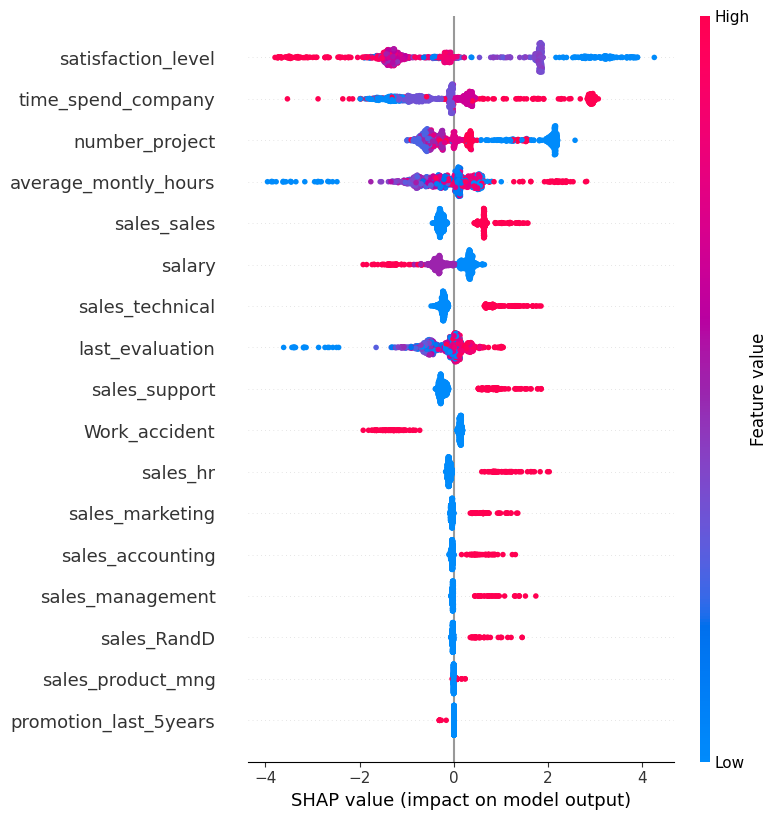


--- Done ---
Notebook has run all steps: EDA, clustering, preprocessing, SMOTE, CV, model training, evaluation, risk zoning, and saved best model.
Recommendations:
 - Choose evaluation metric (Recall vs Precision) depending on HR budget and cost of missed leavers.
 - Pilot targeted interventions for Orange/Red zones to measure ROI before scaling.
 - Re-train model periodically and monitor drift.


In [10]:
# ---------- Step 14: Retention strategy suggestions per zone (printed) ----------
print("\n--- Retention Strategies by Zone ---")
print("\nGreen (Safe) - Score < 20%:")
print("  - Monitor with light-touch engagement: quarterly surveys, training invites, recognition emails.")
print("  - No immediate expensive action required; automate monitoring for upward movement to higher risk.")

print("\nYellow (Low-Risk) - 20% ≤ Score < 60%:")
print("  - Manager check-ins, mentorship programs, recognition, small career-growth nudges, flexible benefits.")
print("  - Run pulse surveys to determine cause (workload, manager relation, compensation expectations).")

print("\nOrange (Medium-Risk) - 60% ≤ Score < 90%:")
print("  - Proactive one-on-one with HR and manager, tailored retention conversations.")
print("  - Assess compensation, promotion backlog, role fit; offer upskilling, clearer career path, workload changes.")

print("\nRed (High-Risk) - Score ≥ 90%:")
print("  - Immediate priority outreach: stay interview, retention package if high-value, senior leadership involvement.")
print("  - Fast-track career path or compensation if justified; consider counteroffer carefully with ROI analysis.")

# ---------- Step 15: Save artifacts (model and feature columns) ----------
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
model_file = f"best_model_{best_model_name}_{timestamp}.pkl"
features_file = f"model_features_{timestamp}.pkl"
joblib.dump(best_model, model_file)
joblib.dump(feature_columns, features_file)
print(f"\nSaved best model to '{model_file}' and feature list to '{features_file}'. Download them from Colab files panel.")

# ---------- Step 16: Optional - SHAP explanations (if shap installed) ----------
try:
    import shap
    print("\n--- SHAP summary (this may take a while for large datasets) ---")
    # For tree models use TreeExplainer; for LR use KernelExplainer (slower)
    if isinstance(best_model, (RandomForestClassifier, GradientBoostingClassifier)):
        explainer = shap.TreeExplainer(best_model)
        # use a sample of training data for speed
        X_for_shap = X_train_smote.sample(n=min(1000, X_train_smote.shape[0]), random_state=123)
        shap_values = explainer.shap_values(X_for_shap)
        # For binary classification, shap_values is a list: shap_values[1] is for positive class
        if isinstance(shap_values, list):
            shap.summary_plot(shap_values[1], X_for_shap, show=True)
        else:
            shap.summary_plot(shap_values, X_for_shap, show=True)
    else:
        print("SHAP TreeExplainer recommended for tree models. For logistic, KernelExplainer is slow.")
except Exception as e:
    print("SHAP not available or failed to run. Install shap to get feature explanations. Error:", e)

# ---------- Step 17: Final notes ----------
print("\n--- Done ---")
print("Notebook has run all steps: EDA, clustering, preprocessing, SMOTE, CV, model training, evaluation, risk zoning, and saved best model.")
print("Recommendations:")
print(" - Choose evaluation metric (Recall vs Precision) depending on HR budget and cost of missed leavers.")
print(" - Pilot targeted interventions for Orange/Red zones to measure ROI before scaling.")
print(" - Re-train model periodically and monitor drift.")